<a href="https://colab.research.google.com/github/Sama-Elmogy/Deep-learing-neural-network-ITI-tasks-/blob/main/DAY_1_TASK_churn_modeling__Sama_Ahmed_Elmogy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install optuna hyperopt tensorflow scikit-learn pandas -q

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix, roc_auc_score, accuracy_score, classification_report,precision_score , recall_score, f1_score

import optuna

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from hyperopt.pyll import scope

#**The bengaluru dataset**

In [6]:
df = pd.read_csv('/content/Churn_Modelling.csv',sep=',')
print("Shape:", df.shape)
print("              First 5 Rows")
print(df.head())

Shape: (10000, 14)
              First 5 Rows
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       

In [7]:
print(" Dataset Info:")
print(df.info())

print("Column names:")
print(df.columns.tolist())


print(" Missing Values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geogr

#**EDA**

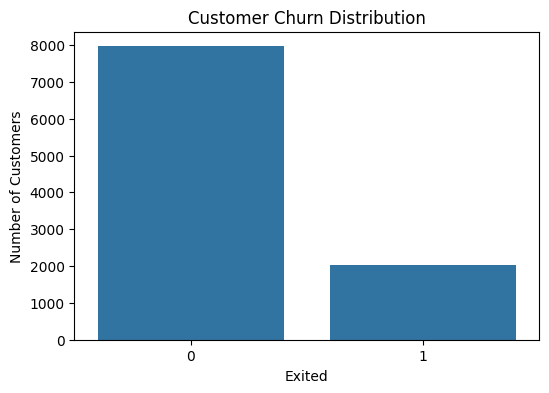

In [8]:
#Overall target distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    df,
    x="Exited"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.show()

In [9]:
print(df["Exited"].value_counts())

print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# from here we can conclue that there is an imbalance

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


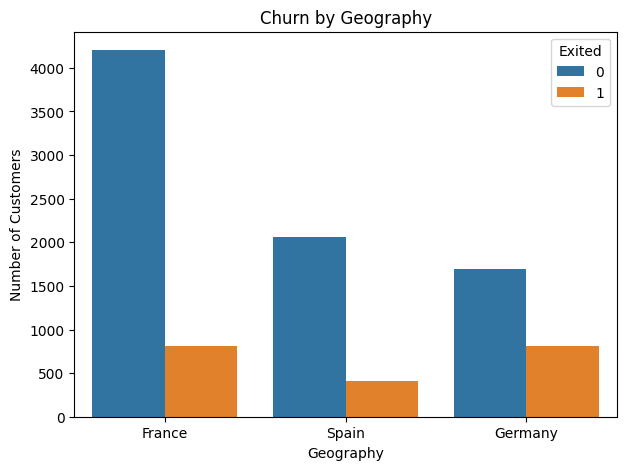

In [10]:
#percentage & visualization of customers who exited within each country.
geo_churn = pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
) * 100

print(geo_churn)

plt.figure(figsize=(7, 5))

sns.countplot(
    df,
    x="Geography",
    hue="Exited"
)

plt.title("Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")

plt.show()

             mean  median  min  max
Exited                             
0       37.408389    36.0   18   92
1       44.837997    45.0   18   84


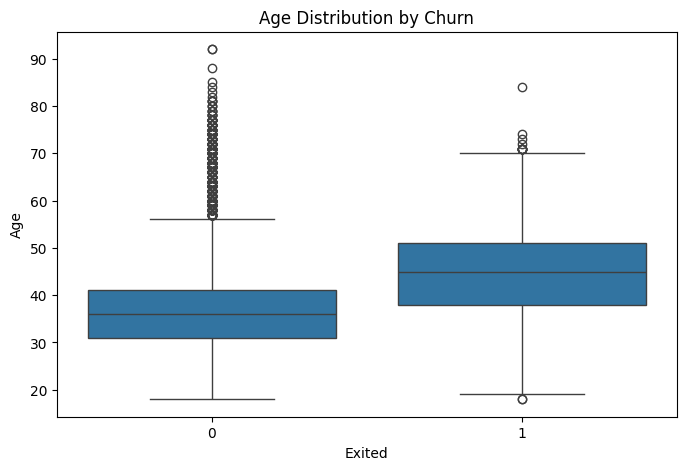

In [11]:
# we can see whether customers who left tend to be older
print(
    df.groupby("Exited")["Age"].agg(
        ["mean", "median", "min", "max"]
    )
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age"
)

plt.title("Age Distribution by Churn")
plt.xlabel("Exited")
plt.ylabel("Age")

plt.show()

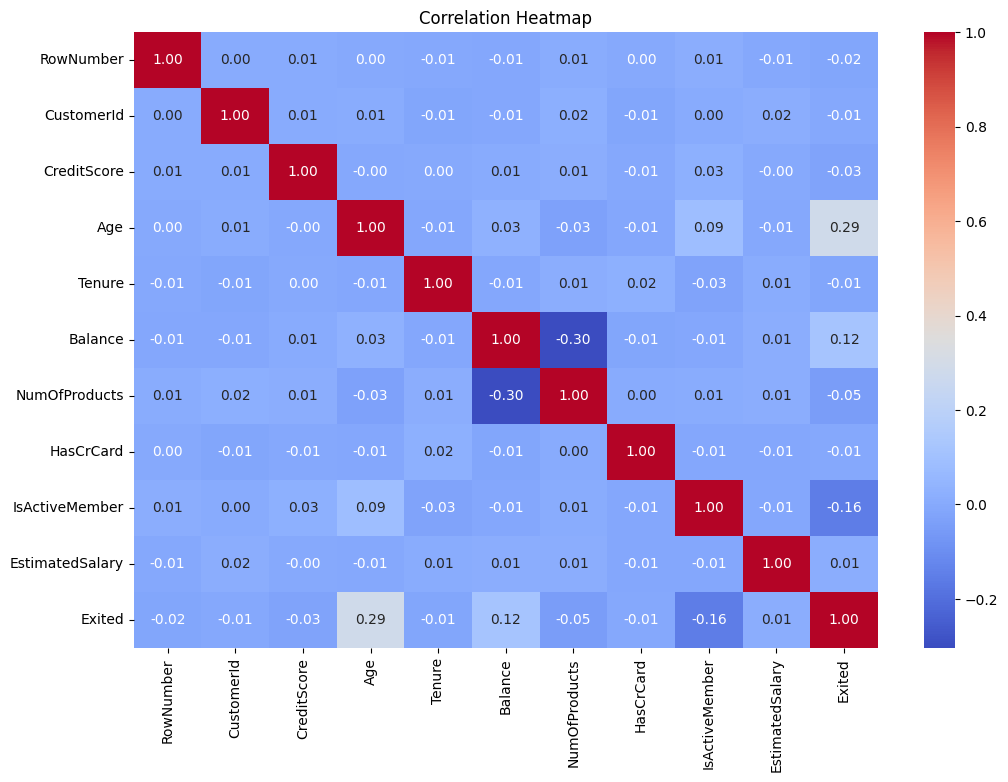

In [12]:
#cannot calculate correlation for Geography and Gender because they are categorical
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

#**Preparing the data for deep learing**

In [13]:
df_clean = df.copy()

df_clean = df_clean.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

print(df_clean.shape)
print(df_clean.head())

(10000, 11)
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [14]:
#separating x & y
X = df.drop(
    columns=["Exited"]
)

y = df["Exited"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# train/ test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X shape: (10000, 13)
y shape: (10000,)
X_train: (8000, 13)
X_test: (2000, 13)
y_train: (8000,)
y_test: (2000,)


In [15]:
#Identifing categorical and numerical columns

categorical_features = [
    "Geography",
    "Gender"
]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

#encoding and scaling
# one hot encoding for categorical features
#standard scaler for numerical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [16]:
# fiting the training data
# i did this  to avoidinformation from the test set leaking into training
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print(
    "Training processed shape:",
    X_train_processed.shape
)

print(
    "Testing processed shape:",
    X_test_processed.shape
)

Training processed shape: (8000, 13)
Testing processed shape: (2000, 13)


#**Training the deep learing model**


In [17]:
def build_baseline_model():

    model = keras.Sequential([

        layers.Input(
            shape=(X_train_processed.shape[1],)
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=[
            "accuracy"
        ]
    )

    return model

In [18]:
baseline_model = build_baseline_model()

baseline_history = baseline_model.fit(
    X_train_processed,
    y_train,

    validation_split=0.2,

    epochs=50,

    batch_size=32,

    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True
        )
    ],

    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8033 - loss: 0.4623 - val_accuracy: 0.8288 - val_loss: 0.4217
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8230 - loss: 0.4208 - val_accuracy: 0.8456 - val_loss: 0.3938
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8313 - loss: 0.4003 - val_accuracy: 0.8600 - val_loss: 0.3669
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8423 - loss: 0.3809 - val_accuracy: 0.8637 - val_loss: 0.3491
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8455 - loss: 0.3697 - val_accuracy: 0.8656 - val_loss: 0.3397
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8497 - loss: 0.3682 - val_accuracy: 0.8669 - val_loss: 0.3395
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8506 - loss: 0.3617 - val_accuracy: 0.8681 - val_loss: 0.3344
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8556 - loss: 0.3582 - val_accuracy: 0.

Baseline Accuracy %: 86.2999975681305
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



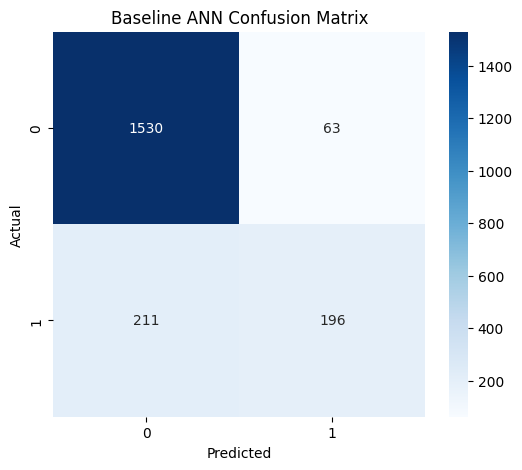

In [19]:
baseline_loss, baseline_accuracy = (
    baseline_model.evaluate(
        X_test_processed,
        y_test,
        verbose=0
    )
)

print(
    "Baseline Accuracy %:",
    baseline_accuracy * 100
)
baseline_prob = baseline_model.predict(
    X_test_processed
).ravel()

baseline_pred = (
    baseline_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        baseline_pred
    )
)


#confusion matrix

cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline ANN Confusion Matrix")

plt.show()

#**Now using the optuna hyperparameters**

In [20]:
def objective(trial):

    units1 = trial.suggest_int(
        "units1",
        32,
        256,
        step=32
    )

    units2 = trial.suggest_int(
        "units2",
        16,
        128,
        step=16
    )

    dropout = trial.suggest_float(
        "dropout",
        0.0,
        0.5
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64, 128]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    model = keras.Sequential([

        layers.Input(
            shape=(X_train_processed.shape[1],)
        ),

        layers.Dense(
            units1,
            activation="relu"
        ),

        layers.Dropout(
            dropout
        ),

        layers.Dense(
            units2,
            activation="relu"
        ),

        layers.Dropout(
            dropout
        ),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    if optimizer_name == "adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_processed,
        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=batch_size,

        callbacks=[early_stopping],

        verbose=0
    )

    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    return best_val_accuracy


In [21]:
# start with 30 trial
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

print(
    "Best Validation Accuracy:",
    study.best_value
)

print("\nBest Hyperparameters:")

for key, value in study.best_params.items():

    print(
        f"{key}: {value}"
    )

[I 2026-08-14 19:47:54,469] A new study created in memory with name: no-name-2b108a8f-2402-41fc-bc65-4a67bc4b1efe
[I 2026-08-14 19:48:19,569] Trial 0 finished with value: 0.8706250190734863 and parameters: {'units1': 192, 'units2': 16, 'dropout': 0.39674296825273053, 'learning_rate': 0.00020949699385362815, 'batch_size': 64, 'optimizer': 'rmsprop'}. Best is trial 0 with value: 0.8706250190734863.
[I 2026-08-14 19:48:28,856] Trial 1 finished with value: 0.8762500286102295 and parameters: {'units1': 224, 'units2': 48, 'dropout': 0.3740098197097925, 'learning_rate': 0.001987940494916883, 'batch_size': 32, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.8762500286102295.
[I 2026-08-14 19:48:35,456] Trial 2 finished with value: 0.8774999976158142 and parameters: {'units1': 128, 'units2': 96, 'dropout': 0.11656846726127323, 'learning_rate': 0.0038582693545826208, 'batch_size': 64, 'optimizer': 'adam'}. Best is trial 2 with value: 0.8774999976158142.
[I 2026-08-14 19:49:38,220] Trial 3

Best Validation Accuracy: 0.8793749809265137

Best Hyperparameters:
units1: 224
units2: 128
dropout: 0.2838727229640666
learning_rate: 0.004005371341155747
batch_size: 16
optimizer: rmsprop


In [23]:
print(
    "Best Validation Accuracy:",
    study.best_value
)

print("\nBest Hyperparameters:")

for key, value in study.best_params.items():

    print(
        f"{key}: {value}"
    )

Best Validation Accuracy: 0.8793749809265137

Best Hyperparameters:
units1: 224
units2: 128
dropout: 0.2838727229640666
learning_rate: 0.004005371341155747
batch_size: 16
optimizer: rmsprop


/tmp/ipykernel_65812/1020437608.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(


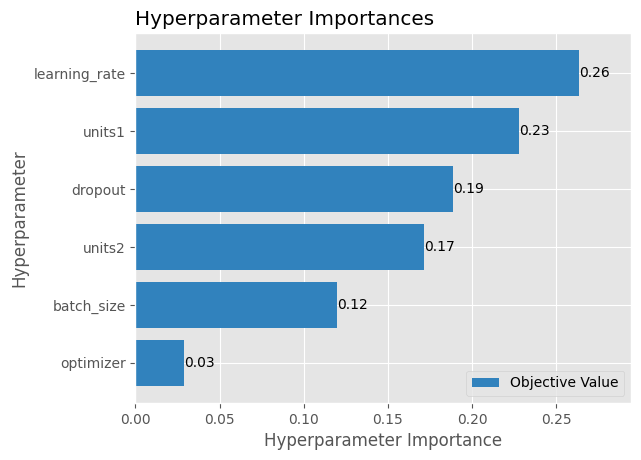

In [24]:
optuna.visualization.matplotlib.plot_param_importances(
    study
)

plt.show()

/tmp/ipykernel_65812/357126150.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(


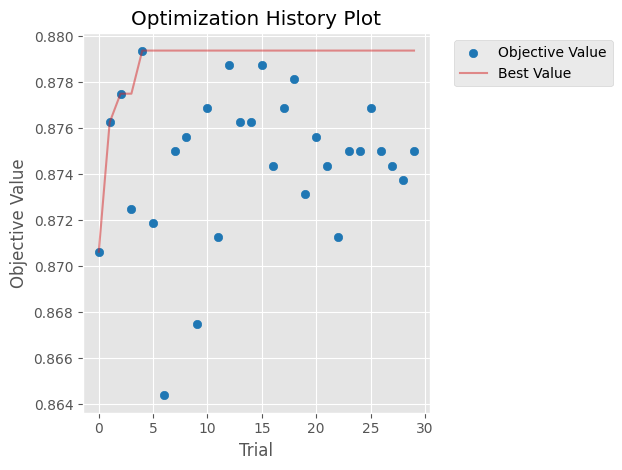

In [25]:
optuna.visualization.matplotlib.plot_optimization_history(
    study
)

plt.show()

#**Training the model with optuna parameters**

In [26]:
# traing the model again
study.best_params

best = study.best_params

final_model = keras.Sequential([

    layers.Input(
        shape=(X_train_processed.shape[1],)
    ),

    layers.Dense(
        best["units1"],
        activation="relu"
    ),

    layers.Dropout(
        best["dropout"]
    ),

    layers.Dense(
        best["units2"],
        activation="relu"
    ),

    layers.Dropout(
        best["dropout"]
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [27]:
#optimizer
if best["optimizer"] == "adam":

    optimizer = keras.optimizers.Adam(
        learning_rate=best["learning_rate"]
    )

else:

    optimizer = keras.optimizers.RMSprop(
        learning_rate=best["learning_rate"]
    )

#compile
final_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# fitting again
final_history = final_model.fit(

    X_train_processed,
    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=best["batch_size"],

    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],

    verbose=1
)


Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8270 - loss: 0.4182 - val_accuracy: 0.8650 - val_loss: 0.3469
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8498 - loss: 0.3837 - val_accuracy: 0.8725 - val_loss: 0.3421
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 0.3792 - val_accuracy: 0.8662 - val_loss: 0.3473
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8537 - loss: 0.3756 - val_accuracy: 0.8687 - val_loss: 0.3532
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8541 - loss: 0.3728 - val_accuracy: 0.8681 - val_loss: 0.3726
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8545 - loss: 0.3693 - val_accuracy: 0.8650 - val_loss: 0.3697
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8583 - loss: 0.3684 - val_accuracy: 0.8700 - val_loss: 0.3571
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8573 - loss: 0.3661 - val_accu

In [28]:
final_prob = final_model.predict(
    X_test_processed
).ravel()

final_pred = (
    final_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        final_pred
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        final_pred
    )
)

print(
    "Accuracy %:",
    accuracy_score(
        y_test,
        final_pred
    ) * 100
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        final_prob
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.84      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

Accuracy: 0.8655
Accuracy %: 86.55000000000001
ROC-AUC: 0.8510313086584272
